<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/DBSCAN_un.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!

Dataset Shape:
(62423, 3)

Columns:
['movieId', 'title', 'genres']

First 5 Rows:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Genre Features:
   (no genres listed)  Action  Adventure  Animation  Children  Comedy  Crime  \
0                   0       0          1          1         1       1      0   
1                   0       0          1          0         1       0      0   
2                   0       0       

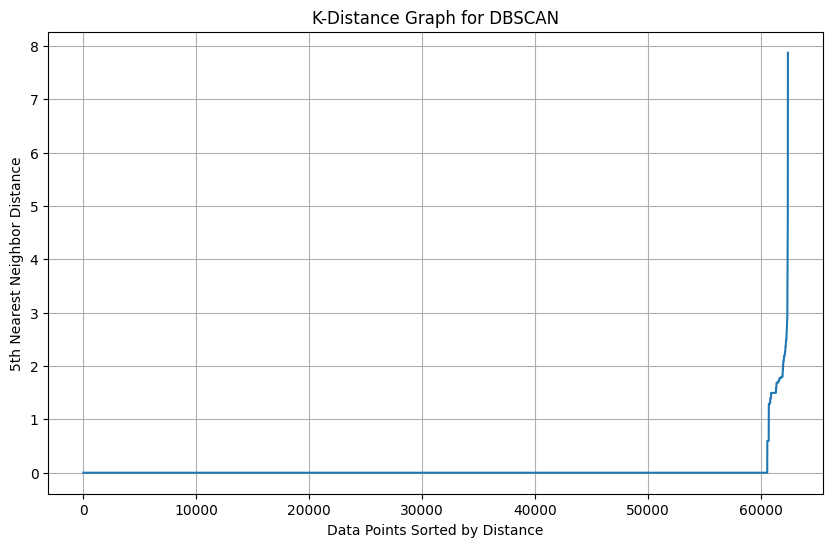


DBSCAN CLUSTER RESULTS
    movieId                                  title  \
0         1                       Toy Story (1995)   
1         2                         Jumanji (1995)   
2         3                Grumpier Old Men (1995)   
3         4               Waiting to Exhale (1995)   
4         5     Father of the Bride Part II (1995)   
5         6                            Heat (1995)   
6         7                         Sabrina (1995)   
7         8                    Tom and Huck (1995)   
8         9                    Sudden Death (1995)   
9        10                       GoldenEye (1995)   
10       11         American President, The (1995)   
11       12     Dracula: Dead and Loving It (1995)   
12       13                           Balto (1995)   
13       14                           Nixon (1995)   
14       15                Cutthroat Island (1995)   
15       16                          Casino (1995)   
16       17           Sense and Sensibility (1995)   
17  

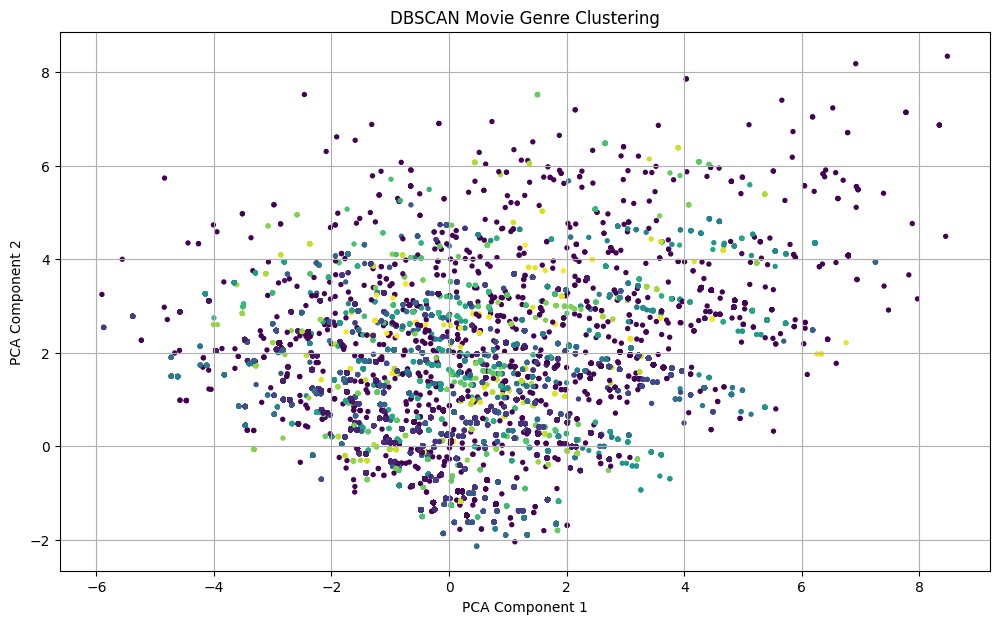

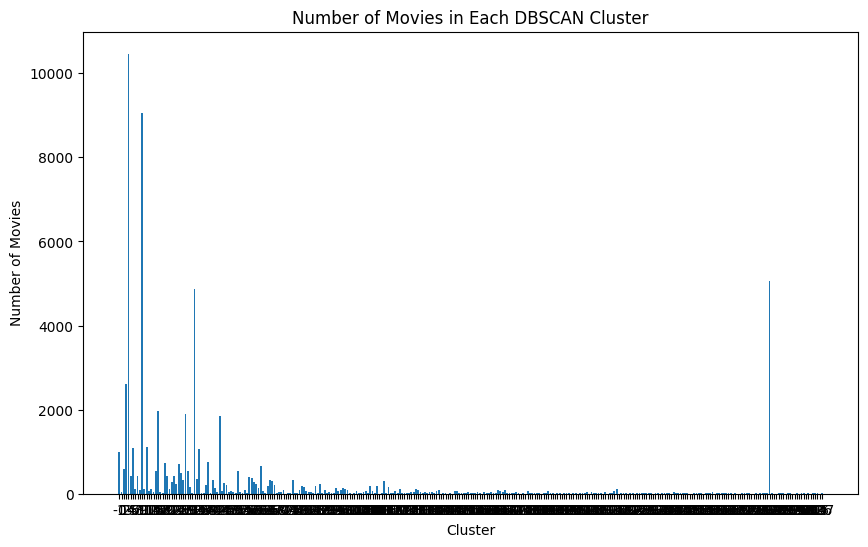


Silhouette Score: 0.676

CLUSTER-WISE MOVIE EXAMPLES

Cluster -1:
                                                          title                                          genres
City of Lost Children, The (Cité des enfants perdus, La) (1995)          Adventure|Drama|Fantasy|Mystery|Sci-Fi
                                        Wings of Courage (1995)                          Adventure|Romance|IMAX
                                              Pocahontas (1995)        Animation|Children|Drama|Musical|Romance
                                  Muppet Treasure Island (1996)               Adventure|Children|Comedy|Musical
                                               Apollo 13 (1995)                            Adventure|Drama|IMAX
                                            Strange Days (1995)      Action|Crime|Drama|Mystery|Sci-Fi|Thriller
                                             Bushwhacked (1995)                  Adventure|Comedy|Crime|Mystery
                                     

In [1]:
# ============================================================
# DBSCAN CLUSTERING - MOVIES DATASET
# Unsupervised Machine Learning
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("movies.csv")

print("Dataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

df["genres"] = df["genres"].fillna("Unknown")

# ============================================================
# 3. CONVERT GENRES INTO NUMERICAL FEATURES
# ============================================================

# Split multiple genres
genre_list = df["genres"].apply(
    lambda x: x.split("|")
)

# MultiLabelBinarizer
mlb = MultiLabelBinarizer()

genre_features = mlb.fit_transform(
    genre_list
)

genre_df = pd.DataFrame(
    genre_features,
    columns=mlb.classes_
)

print("\nGenre Features:")
print(genre_df.head())

print("\nNumber of Genre Features:")
print(genre_df.shape[1])

# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    genre_df
)

print("\nFeature Scaling Completed!")

# ============================================================
# 5. PCA FOR CLUSTERING
# ============================================================

# Reduce dimensions while keeping useful information

pca_cluster = PCA(
    n_components=10,
    random_state=42
)

X_pca_cluster = pca_cluster.fit_transform(
    X_scaled
)

print("\nPCA for Clustering Completed!")

print(
    "Explained Variance:",
    round(
        pca_cluster.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

# ============================================================
# 6. K-DISTANCE GRAPH
# ============================================================

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X_pca_cluster)

distances, indices = neighbors.kneighbors(
    X_pca_cluster
)

# Take distance to 5th nearest neighbor

k_distances = np.sort(
    distances[:, 4]
)

plt.figure(figsize=(10, 6))

plt.plot(
    k_distances
)

plt.xlabel("Data Points Sorted by Distance")

plt.ylabel("5th Nearest Neighbor Distance")

plt.title(
    "K-Distance Graph for DBSCAN"
)

plt.grid(True)

plt.show()

# ============================================================
# 7. APPLY DBSCAN
# ============================================================

# You can adjust these values based on
# the K-Distance graph

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

clusters = dbscan.fit_predict(
    X_pca_cluster
)

# Add cluster labels

df["Cluster"] = clusters

# ============================================================
# 8. DISPLAY CLUSTER RESULTS
# ============================================================

print("\n======================================")
print("DBSCAN CLUSTER RESULTS")
print("======================================")

print(
    df[
        [
            "movieId",
            "title",
            "genres",
            "Cluster"
        ]
    ].head(20)
)

# ============================================================
# 9. COUNT CLUSTERS
# ============================================================

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nMovies in Each Cluster:")

print(cluster_counts)

# ============================================================
# 10. NUMBER OF CLUSTERS
# ============================================================

unique_clusters = set(
    clusters
)

# Remove -1 because -1 represents noise

if -1 in unique_clusters:
    unique_clusters.remove(-1)

number_of_clusters = len(
    unique_clusters
)

print(
    "\nNumber of Clusters:",
    number_of_clusters
)

# ============================================================
# 11. NOISE POINTS
# ============================================================

noise_count = (
    df["Cluster"] == -1
).sum()

print(
    "Number of Noise Movies:",
    noise_count
)

# ============================================================
# 12. PCA FOR 2D VISUALIZATION
# ============================================================

pca_visual = PCA(
    n_components=2,
    random_state=42
)

X_visual = pca_visual.fit_transform(
    X_scaled
)

df["PCA1"] = X_visual[:, 0]
df["PCA2"] = X_visual[:, 1]

# ============================================================
# 13. DBSCAN CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))

plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["Cluster"],
    s=8
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title(
    "DBSCAN Movie Genre Clustering"
)

plt.grid(True)

plt.show()

# ============================================================
# 14. CLUSTER COUNT VISUALIZATION
# ============================================================

cluster_plot = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    cluster_plot.index.astype(str),
    cluster_plot.values
)

plt.xlabel("Cluster")

plt.ylabel("Number of Movies")

plt.title(
    "Number of Movies in Each DBSCAN Cluster"
)

plt.show()

# ============================================================
# 15. SILHOUETTE SCORE
# ============================================================

# Remove noise for silhouette calculation

non_noise = (
    df["Cluster"] != -1
)

valid_clusters = df.loc[
    non_noise,
    "Cluster"
]

if (
    number_of_clusters >= 2
    and non_noise.sum() > number_of_clusters
):

    score = silhouette_score(
        X_pca_cluster[non_noise],
        valid_clusters
    )

    print(
        "\nSilhouette Score:",
        round(score, 4)
    )

else:

    print(
        "\nSilhouette Score cannot be calculated."
    )

# ============================================================
# 16. CLUSTER-WISE MOVIE EXAMPLES
# ============================================================

print("\n======================================")
print("CLUSTER-WISE MOVIE EXAMPLES")
print("======================================")

for cluster in sorted(
    df["Cluster"].unique()
):

    print(
        f"\nCluster {cluster}:"
    )

    cluster_movies = df[
        df["Cluster"] == cluster
    ][
        [
            "title",
            "genres"
        ]
    ].head(10)

    print(
        cluster_movies.to_string(
            index=False
        )
    )

# ============================================================
# 17. NOISE MOVIES
# ============================================================

noise_movies = df[
    df["Cluster"] == -1
]

print("\n======================================")
print("NOISE MOVIES")
print("======================================")

print(
    noise_movies[
        [
            "title",
            "genres"
        ]
    ].head(10)
)

# ============================================================
# 18. SAVE RESULTS
# ============================================================

df.to_csv(
    "movies_DBSCAN_results.csv",
    index=False
)

print(
    "\nResults saved as:"
)

print(
    "movies_DBSCAN_results.csv"
)

# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n======================================")
print("DBSCAN COMPLETED")
print("======================================")

print(
    "Total Movies:",
    len(df)
)

print(
    "Total Clusters:",
    number_of_clusters
)

print(
    "Noise Movies:",
    noise_count
)